# Modelo: XGBoost
# Autor: Mireya

## Objetivo
Construir un modelo base con XGBoost para predecir la probabilidad de conversión de los clientes.

La validación se realizará de forma temporal:
- Entrenamiento: enero a octubre de 2026
- Validación: noviembre de 2026
- Test final: diciembre de 2026

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [5]:
train = pd.read_csv("../../../data/raw/train.csv")
test = pd.read_csv("../../../data/raw/test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

display(train.head())
display(test.head())

Train: (110100, 25)
Test: (9900, 24)


,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,...,es_nuevo_cliente,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo
0,1,202601,26,42120.349663,0.367310,139,2,40949.765573,67,professional,...,False,False,222,10,9.898223,android,21,True,67,0
1,2,202601,56,89837.390440,0.338092,29,2,35233.622561,304,manager,...,False,False,58,2,9.311922,ios,20,True,304,0
2,3,202601,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,...,False,False,8,6,12.188249,android,12,False,220,0
3,4,202601,62,54673.148516,0.243261,43,2,300.000000,110,manual,...,False,False,119,9,10.459796,ios,20,False,110,0
4,5,202601,37,100239.135609,0.230946,113,1,32066.808006,247,professional,...,False,False,25,6,36.502645,ios,13,False,247,1


,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,...,activo_movil,es_nuevo_cliente,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion
0,2,202612,56,89837.390440,0.338092,29,2,35233.622561,304,manager,...,True,False,False,58,2,9.311922,ios,20,True,263
1,3,202612,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,...,True,False,False,8,6,12.188249,android,12,False,3
2,7,202612,26,68519.815499,0.175526,135,1,33288.859454,269,manual,...,True,False,True,179,9,6.483404,android,5,False,102
3,10,202612,63,62055.894781,0.122771,77,2,28642.298570,216,clerical,...,True,True,True,129,5,3.034573,web,2,False,263
4,11,202612,33,54626.454236,0.340273,176,2,51015.363541,304,clerical,...,False,False,True,111,8,20.905989,web,24,False,309


In [6]:
print(train.columns.tolist())
print(test.columns.tolist())

['id_cliente', 'mes', 'edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses', 'numero_productos', 'saldo_promedio', 'dias_ultima_transaccion', 'ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'antiguedad_direccion_meses', 'visitas_web_ultimos_90_dias', 'distancia_sucursal_km', 'dispositivo_principal', 'dia_preferido_pago', 'tiene_seguro', 'dias_ultima_interaccion', 'objetivo']
['id_cliente', 'mes', 'edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses', 'numero_productos', 'saldo_promedio', 'dias_ultima_transaccion', 'ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'antiguedad_direccion_meses', 'visitas_web_ultimos_90_dias', 'distancia_sucursal_km', 'dispositivo_principal', 'dia_preferido_pago', 'tiene_seguro', 'dias_ultima_interaccion']


In [7]:
print("Meses train:", sorted(train["mes"].unique()))
print("Meses test:", sorted(test["mes"].unique()))

print("\nDistribución objetivo:")
print(train["objetivo"].value_counts())

print("\nProporción:")
print(train["objetivo"].value_counts(normalize=True))

Meses train: [np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604), np.int64(202605), np.int64(202606), np.int64(202607), np.int64(202608), np.int64(202609), np.int64(202610), np.int64(202611)]
Meses test: [np.int64(202612)]

Distribución objetivo:
objetivo
0    93533
1    16567
Name: count, dtype: int64

Proporción:
objetivo
0    0.849528
1    0.150472
Name: proportion, dtype: float64


In [8]:
print("Nulos train:")
print(train.isnull().sum().sort_values(ascending=False).head(10))

print("\nNulos test:")
print(test.isnull().sum().sort_values(ascending=False).head(10))

Nulos train:
id_cliente                 0
mes                        0
edad                       0
ingresos                   0
ratio_deuda_ingresos       0
antiguedad_cuenta_meses    0
numero_productos           0
saldo_promedio             0
dias_ultima_transaccion    0
ocupacion                  0
dtype: int64

Nulos test:
id_cliente                 0
mes                        0
edad                       0
ingresos                   0
ratio_deuda_ingresos       0
antiguedad_cuenta_meses    0
numero_productos           0
saldo_promedio             0
dias_ultima_transaccion    0
ocupacion                  0
dtype: int64


In [9]:
train.dtypes

id_cliente                       int64
mes                              int64
edad                             int64
ingresos                       float64
ratio_deuda_ingresos           float64
antiguedad_cuenta_meses          int64
numero_productos                 int64
saldo_promedio                 float64
dias_ultima_transaccion          int64
ocupacion                       object
region                          object
canal_adquisicion               object
banda_riesgo                    object
tiene_tarjeta_credito             bool
activo_movil                      bool
es_nuevo_cliente                  bool
tiene_prestamo                    bool
antiguedad_direccion_meses       int64
visitas_web_ultimos_90_dias      int64
distancia_sucursal_km          float64
dispositivo_principal           object
dia_preferido_pago               int64
tiene_seguro                      bool
dias_ultima_interaccion          int64
objetivo                         int64
dtype: object

In [10]:
train_model = train[train["mes"] < 202611].copy()
val = train[train["mes"] == 202611].copy()

print("Train temporal:", train_model.shape)
print("Validación:", val.shape)

print("Meses train:", sorted(train_model["mes"].unique()))
print("Mes validación:", val["mes"].unique())

Train temporal: (100600, 25)
Validación: (9500, 25)
Meses train: [np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604), np.int64(202605), np.int64(202606), np.int64(202607), np.int64(202608), np.int64(202609), np.int64(202610)]
Mes validación: [202611]


In [11]:
X_train = train_model.drop(columns=["objetivo", "id_cliente"])
y_train = train_model["objetivo"]

X_val = val.drop(columns=["objetivo", "id_cliente"])
y_val = val["objetivo"]

In [12]:
categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Variables categóricas:")
print(categoricas)

Variables categóricas:
['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']


In [13]:
X_train = pd.get_dummies(
    X_train,
    columns=categoricas,
    drop_first=False
)

X_val = pd.get_dummies(
    X_val,
    columns=categoricas,
    drop_first=False
)

In [14]:
X_train, X_val = X_train.align(
    X_val,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train.shape)
print(X_val.shape)

(100600, 40)
(9500, 40)


In [15]:
modelo = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

In [16]:
modelo.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [17]:
pred_val = modelo.predict_proba(X_val)[:, 1]

In [18]:
auc = roc_auc_score(y_val, pred_val)
gini = 2 * auc - 1

print("ROC AUC:", auc)
print("Gini:", gini)

ROC AUC: 0.6133299177510192
Gini: 0.2266598355020384


Experimentación borrando mes 

In [19]:
X_train_2 = train_model.drop(columns=["objetivo", "id_cliente", "mes"])
y_train_2 = train_model["objetivo"]

X_val_2 = val.drop(columns=["objetivo", "id_cliente", "mes"])
y_val_2 = val["objetivo"]

In [20]:
categoricas_2 = X_train_2.select_dtypes(include=["object"]).columns.tolist()

X_train_2 = pd.get_dummies(
    X_train_2,
    columns=categoricas_2,
    drop_first=False
)

X_val_2 = pd.get_dummies(
    X_val_2,
    columns=categoricas_2,
    drop_first=False
)

X_train_2, X_val_2 = X_train_2.align(
    X_val_2,
    join="left",
    axis=1,
    fill_value=0
)

In [21]:
modelo_2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

modelo_2.fit(X_train_2, y_train_2)

pred_val_2 = modelo_2.predict_proba(X_val_2)[:, 1]

auc_2 = roc_auc_score(y_val_2, pred_val_2)
gini_2 = 2 * auc_2 - 1

print("ROC AUC sin mes:", auc_2)
print("Gini sin mes:", gini_2)

ROC AUC sin mes: 0.6141679078541066
Gini sin mes: 0.22833581570821315


creando una variable temporable

In [22]:
train_fe = train.sort_values(["id_cliente", "mes"]).copy()

In [23]:
train_fe["meses_observado"] = (
    train_fe.groupby("id_cliente").cumcount() + 1
)

In [24]:
train_fe[
    train_fe["id_cliente"] == 26
][["id_cliente", "mes", "meses_observado", "objetivo"]]

,id_cliente,mes,meses_observado,objetivo
25,26,202601,1,0
10420,26,202602,2,0
20219,26,202603,3,0
30519,26,202604,4,1


In [25]:
train_model_3 = train_fe[train_fe["mes"] < 202611].copy()
val_3 = train_fe[train_fe["mes"] == 202611].copy()

In [26]:
X_train_3 = train_model_3.drop(columns=["objetivo", "id_cliente", "mes"])
y_train_3 = train_model_3["objetivo"]

X_val_3 = val_3.drop(columns=["objetivo", "id_cliente", "mes"])
y_val_3 = val_3["objetivo"]

In [27]:
categoricas_3 = X_train_3.select_dtypes(include=["object"]).columns.tolist()

X_train_3 = pd.get_dummies(
    X_train_3,
    columns=categoricas_3,
    drop_first=False
)

X_val_3 = pd.get_dummies(
    X_val_3,
    columns=categoricas_3,
    drop_first=False
)

X_train_3, X_val_3 = X_train_3.align(
    X_val_3,
    join="left",
    axis=1,
    fill_value=0
)

In [28]:
modelo_3 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

modelo_3.fit(X_train_3, y_train_3)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [29]:
pred_val_3 = modelo_3.predict_proba(X_val_3)[:, 1]

auc_3 = roc_auc_score(y_val_3, pred_val_3)
gini_3 = 2 * auc_3 - 1

print("ROC AUC + meses_observado:", auc_3)
print("Gini + meses_observado:", gini_3)

ROC AUC + meses_observado: 0.6155055626490815
Gini + meses_observado: 0.23101112529816303


In [30]:
train_fe = train_fe.sort_values(["id_cliente", "mes"])

train_fe["interaccion_anterior"] = (
    train_fe.groupby("id_cliente")["dias_ultima_interaccion"].shift(1)
)

train_fe["cambio_interaccion"] = (
    train_fe["dias_ultima_interaccion"] -
    train_fe["interaccion_anterior"]
)

In [31]:
train_fe["interaccion_anterior"] = train_fe["interaccion_anterior"].fillna(0)
train_fe["cambio_interaccion"] = train_fe["cambio_interaccion"].fillna(0)

última interacción

In [32]:
train_fe = train_fe.sort_values(["id_cliente", "mes"])

train_fe["interaccion_anterior"] = (
    train_fe.groupby("id_cliente")["dias_ultima_interaccion"].shift(1)
)

train_fe["cambio_interaccion"] = (
    train_fe["dias_ultima_interaccion"] -
    train_fe["interaccion_anterior"]
)

In [33]:
train_fe["interaccion_anterior"] = (
    train_fe["interaccion_anterior"].fillna(0)
)

train_fe["cambio_interaccion"] = (
    train_fe["cambio_interaccion"].fillna(0)
)

In [34]:
train_fe[
    train_fe["id_cliente"] == 2
][[
    "id_cliente",
    "mes",
    "dias_ultima_interaccion",
    "interaccion_anterior",
    "cambio_interaccion",
    "meses_observado",
    "objetivo"
]]

,id_cliente,mes,dias_ultima_interaccion,interaccion_anterior,cambio_interaccion,meses_observado,objetivo
1,2,202601,304,0.0,0.0,1,0
10401,2,202602,304,304.0,0.0,2,0
20201,2,202603,236,304.0,-68.0,3,0
30501,2,202604,128,236.0,-108.0,4,0
40101,2,202605,304,128.0,176.0,5,0
50201,2,202606,304,304.0,0.0,6,0
60550,2,202607,137,304.0,-167.0,7,0
70250,2,202608,70,137.0,-67.0,8,0
80300,2,202609,302,70.0,232.0,9,0
90200,2,202610,279,302.0,-23.0,10,0


In [35]:
train_model_4 = train_fe[train_fe["mes"] < 202611].copy()
val_4 = train_fe[train_fe["mes"] == 202611].copy()

print(train_model_4.shape)
print(val_4.shape)

(100600, 28)
(9500, 28)


In [36]:
X_train_4 = train_model_4.drop(
    columns=["objetivo", "id_cliente", "mes"]
)

y_train_4 = train_model_4["objetivo"]

X_val_4 = val_4.drop(
    columns=["objetivo", "id_cliente", "mes"]
)

y_val_4 = val_4["objetivo"]

In [37]:
categoricas_4 = X_train_4.select_dtypes(
    include=["object"]
).columns.tolist()

print(categoricas_4)

['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']


In [38]:
X_train_4 = pd.get_dummies(
    X_train_4,
    columns=categoricas_4,
    drop_first=False
)

X_val_4 = pd.get_dummies(
    X_val_4,
    columns=categoricas_4,
    drop_first=False
)

In [39]:
X_train_4, X_val_4 = X_train_4.align(
    X_val_4,
    join="left",
    axis=1,
    fill_value=0
)

print("Train:", X_train_4.shape)
print("Val:", X_val_4.shape)

Train: (100600, 42)
Val: (9500, 42)


In [40]:
modelo_4 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

modelo_4.fit(X_train_4, y_train_4)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [41]:
pred_val_4 = modelo_4.predict_proba(X_val_4)[:, 1]

In [42]:
auc_4 = roc_auc_score(y_val_4, pred_val_4)
gini_4 = 2 * auc_4 - 1

print("ROC AUC + historial interacción:", auc_4)
print("Gini + historial interacción:", gini_4)

ROC AUC + historial interacción: 0.6150279673431709
Gini + historial interacción: 0.23005593468634178


antiguedad?

In [43]:
train_fe["grupo_antiguedad_cuenta"] = pd.cut(
    train_fe["antiguedad_cuenta_meses"],
    bins=[-1, 12, 36, 60, 120, 9999],
    labels=[
        "0-12",
        "13-36",
        "37-60",
        "61-120",
        "120+"
    ]
)

In [44]:
train_fe[
    ["antiguedad_cuenta_meses", "grupo_antiguedad_cuenta"]
].head(20)

,antiguedad_cuenta_meses,grupo_antiguedad_cuenta
0,139,120+
10400,139,120+
20200,139,120+
30500,139,120+
40100,139,120+
50200,139,120+
1,29,13-36
10401,29,13-36
20201,29,13-36
30501,29,13-36


In [45]:
train_model_5 = train_fe[train_fe["mes"] < 202611].copy()
val_5 = train_fe[train_fe["mes"] == 202611].copy()

In [46]:
X_train_5 = train_model_5.drop(
    columns=["objetivo", "id_cliente", "mes"]
)

y_train_5 = train_model_5["objetivo"]

X_val_5 = val_5.drop(
    columns=["objetivo", "id_cliente", "mes"]
)

y_val_5 = val_5["objetivo"]

In [47]:
categoricas_5 = X_train_5.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(categoricas_5)

['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal', 'grupo_antiguedad_cuenta']


In [48]:
X_train_5 = pd.get_dummies(
    X_train_5,
    columns=categoricas_5,
    drop_first=False
)

X_val_5 = pd.get_dummies(
    X_val_5,
    columns=categoricas_5,
    drop_first=False
)

In [49]:
X_train_5, X_val_5 = X_train_5.align(
    X_val_5,
    join="left",
    axis=1,
    fill_value=0
)

print("Train:", X_train_5.shape)
print("Val:", X_val_5.shape)

Train: (100600, 47)
Val: (9500, 47)


In [50]:
modelo_5 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

modelo_5.fit(X_train_5, y_train_5)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [51]:
pred_val_5 = modelo_5.predict_proba(X_val_5)[:, 1]

In [52]:
auc_5 = roc_auc_score(y_val_5, pred_val_5)
gini_5 = 2 * auc_5 - 1

print("ROC AUC + grupo antiguedad:", auc_5)
print("Gini + grupo antiguedad:", gini_5)

ROC AUC + grupo antiguedad: 0.6170123585975216
Gini + grupo antiguedad: 0.23402471719504314


momento de la verdad'?

In [53]:
train_final = train.copy()
test_final = test.copy()

train_final["es_test"] = 0
test_final["es_test"] = 1

datos_completos = pd.concat(
    [train_final, test_final],
    ignore_index=True
)

datos_completos = datos_completos.sort_values(
    ["id_cliente", "mes"]
)

In [54]:
datos_completos["meses_observado"] = (
    datos_completos.groupby("id_cliente").cumcount() + 1
)

In [55]:
datos_completos["grupo_antiguedad_cuenta"] = pd.cut(
    datos_completos["antiguedad_cuenta_meses"],
    bins=[-1, 12, 36, 60, 120, 9999],
    labels=["0-12", "13-36", "37-60", "61-120", "120+"]
)

In [56]:
train_final = datos_completos[
    datos_completos["es_test"] == 0
].copy()

test_final = datos_completos[
    datos_completos["es_test"] == 1
].copy()

In [57]:
train_final = train_final.drop(columns=["es_test"])
test_final = test_final.drop(columns=["es_test"])

In [58]:
X_final = train_final.drop(
    columns=["objetivo", "id_cliente", "mes"]
)

y_final = train_final["objetivo"]

X_test_final = test_final.drop(
    columns=["objetivo", "id_cliente", "mes"]
)

In [59]:
categoricas_final = X_final.select_dtypes(
    include=["object", "category"]
).columns.tolist()

X_final = pd.get_dummies(
    X_final,
    columns=categoricas_final,
    drop_first=False
)

X_test_final = pd.get_dummies(
    X_test_final,
    columns=categoricas_final,
    drop_first=False
)

X_final, X_test_final = X_final.align(
    X_test_final,
    join="left",
    axis=1,
    fill_value=0
)

In [60]:
modelo_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

modelo_final.fit(X_final, y_final)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [61]:
pred_test = modelo_final.predict_proba(
    X_test_final
)[:, 1]

In [62]:
submission = pd.DataFrame({
    "id_cliente": test_final["id_cliente"].values,
    "prediccion": pred_test
})

submission.head()

,id_cliente,prediccion
0,2,0.126464
1,3,0.094962
2,7,0.137191
3,10,0.072345
4,11,0.150596


In [63]:
submission.to_csv(
    "../../../resultados/predicciones/predicciones_Ortega.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\..\..\resultados\predicciones'

In [64]:
from pathlib import Path

ruta_salida = Path("../../../resultados/predicciones")
ruta_salida.mkdir(parents=True, exist_ok=True)

In [65]:
submission.to_csv(
    ruta_salida / "predicciones_Ortega.csv",
    index=False
)

In [66]:
print(ruta_salida / "predicciones_Ortega.csv")

..\..\..\resultados\predicciones\predicciones_Ortega.csv


In [67]:
print(submission.shape)
print(submission.head())
print(submission.isnull().sum())
print(submission["prediccion"].min())
print(submission["prediccion"].max())

(9900, 2)
   id_cliente  prediccion
0           2    0.126464
1           3    0.094962
2           7    0.137191
3          10    0.072345
4          11    0.150596
id_cliente    0
prediccion    0
dtype: int64
0.015748858
0.48026004


In [68]:
test_orden = test[["id_cliente"]].copy()
test_orden["orden_original"] = range(len(test_orden))

In [69]:
submission_corregido = test_orden.merge(
    submission,
    on="id_cliente",
    how="left"
)

In [70]:
submission_corregido = submission_corregido.sort_values(
    "orden_original"
)

In [71]:
submission_corregido = submission_corregido[
    ["id_cliente", "prediccion"]
]

<Axes: title={'center': 'saldo_promedio'}, xlabel='objetivo'>

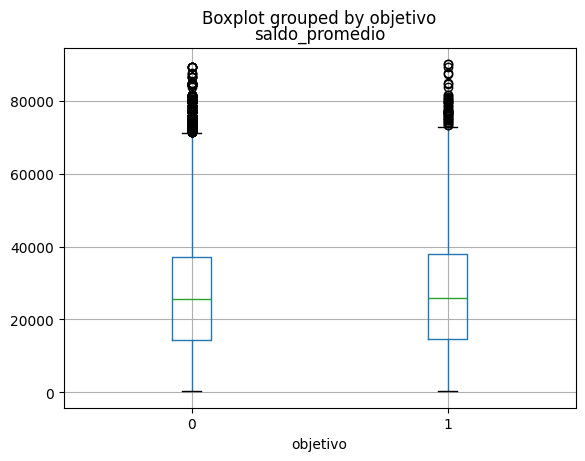

In [76]:
train.boxplot(column="saldo_promedio", by="objetivo")

<Axes: title={'center': 'antiguedad_cuenta_meses'}, xlabel='objetivo'>

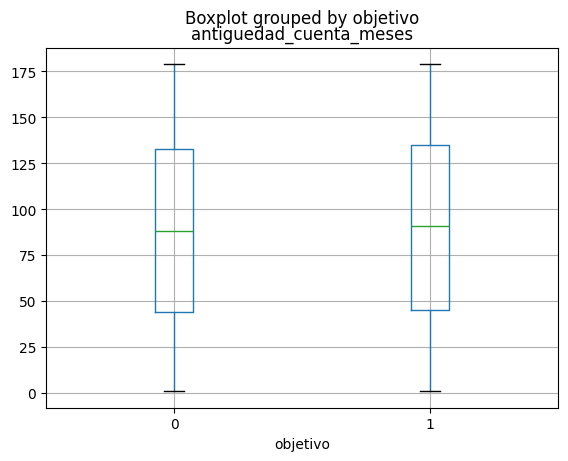

In [77]:
train.boxplot(column="antiguedad_cuenta_meses", by="objetivo")

In [72]:
print(submission_corregido.shape)
print(submission_corregido.head())
print(submission_corregido.isnull().sum())

(9900, 2)
   id_cliente  prediccion
0           2    0.126464
1           3    0.094962
2           7    0.137191
3          10    0.072345
4          11    0.150596
id_cliente    0
prediccion    0
dtype: int64


In [73]:
print(
    submission_corregido["id_cliente"]
    .reset_index(drop=True)
    .equals(test["id_cliente"].reset_index(drop=True))
)

True


In [74]:
submission_corregido.to_csv(
    ruta_salida / "predicciones_Ortega.csv",
    index=False
)

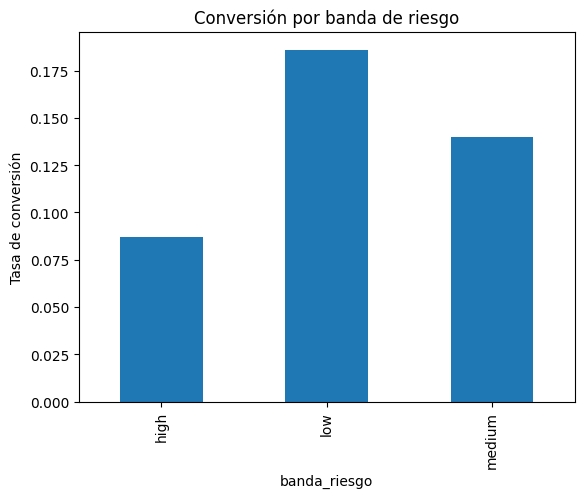

In [78]:
train.groupby("banda_riesgo")["objetivo"].mean().plot(kind="bar")
plt.ylabel("Tasa de conversión")
plt.title("Conversión por banda de riesgo")
plt.show()

In [75]:
submission_corregido.sort_values(
    "prediccion",
    ascending=False
).head(20)

,id_cliente,prediccion
8624,25192,0.480260
8944,25512,0.469013
8104,24672,0.468310
4811,19429,0.461742
7445,23859,0.457944
8855,25423,0.457641
9743,26311,0.456488
9530,26098,0.456260
6815,22941,0.454114
7631,24090,0.453445
